<a href="https://colab.research.google.com/github/Parnita21/MLA0201-Fundamentals-Of-Machine-Learning/blob/main/FOML_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hypothesis after each positive example:
Example 1 : ['Sunny', 'Warm', 'Normal', 'Strong']
Example 2 : ['Sunny', 'Warm', '?', 'Strong']
Example 4 : ['Sunny', 'Warm', '?', '?']

Final Hypothesis: ['Sunny', 'Warm', '?', '?']


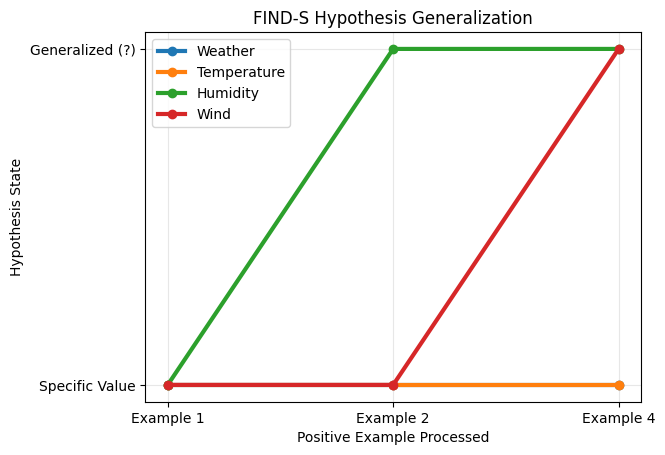

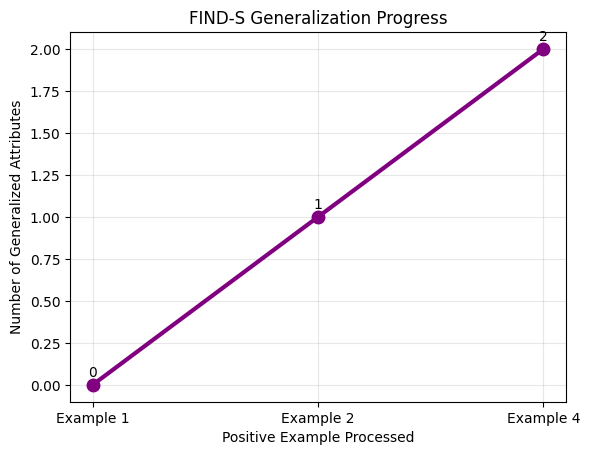

In [ ]:
import matplotlib.pyplot as plt

# Training data
data = [
    ['Sunny','Warm','Normal','Strong','Yes'],
    ['Sunny','Warm','High','Strong','Yes'],
    ['Rainy','Cold','High','Strong','No'],
    ['Sunny','Warm','High','Weak','Yes']
]

attributes = ['Weather','Temperature','Humidity','Wind']

# FIND-S
h = ['Ø'] * 4
history = []
labels = []

for i, row in enumerate(data):
    if row[-1] == 'Yes':
        if h == ['Ø'] * 4:
            h = row[:-1].copy()
        else:
            for j in range(4):
                if h[j] != row[j]:
                    h[j] = '?'

        history.append(h.copy())
        labels.append(f'Example {i+1}')

print("Hypothesis after each positive example:")
for x, y in zip(labels, history):
    print(x, ":", y)

print("\nFinal Hypothesis:", h)

# ------------------------------------------------
# GRAPH 1: Attribute-wise generalization
# ------------------------------------------------

for j, a in enumerate(attributes):
    y = [1 if x[j] == '?' else 0 for x in history]
    plt.plot(labels, y, marker='o', linewidth=3, label=a)

plt.yticks([0,1], ['Specific Value','Generalized (?)'])
plt.xlabel("Positive Example Processed")
plt.ylabel("Hypothesis State")
plt.title("FIND-S Hypothesis Generalization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------
# GRAPH 2: Generalization progress
# ------------------------------------------------

count = [x.count('?') for x in history]

plt.plot(labels, count, marker='o', linewidth=3,
         markersize=9, color='purple')

for i, v in enumerate(count):
    plt.text(i, v+0.05, str(v), ha='center')

plt.xlabel("Positive Example Processed")
plt.ylabel("Number of Generalized Attributes")
plt.title("FIND-S Generalization Progress")
plt.grid(True, alpha=0.3)
plt.show()

Training Data:

     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes

Final Specific Boundary (S):
['Sunny', 'Warm', '?', 'Strong', '?', '?']

Final General Boundary (G):


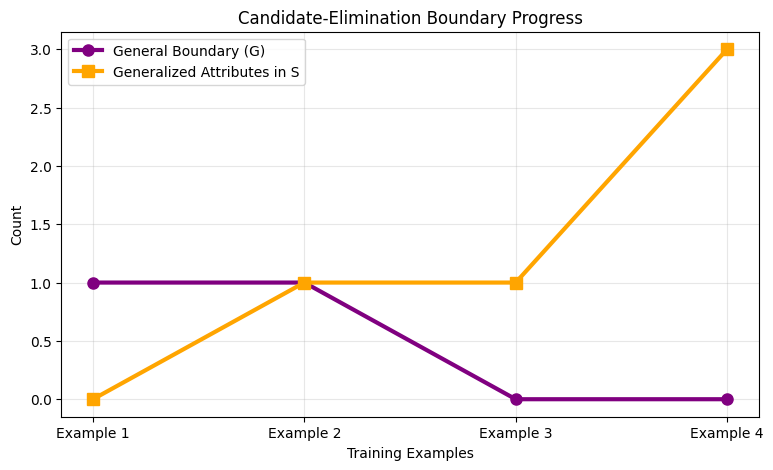

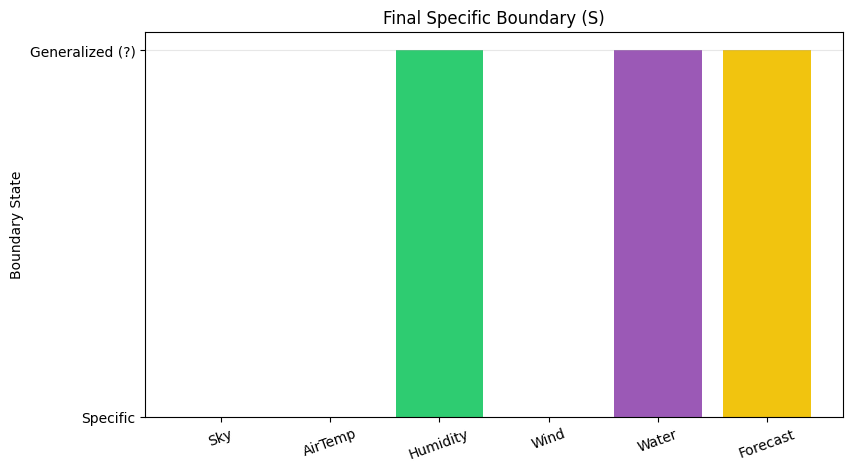

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# CSV training data
csv_data = """Sky,AirTemp,Humidity,Wind,Water,Forecast,EnjoySport
Sunny,Warm,Normal,Strong,Warm,Same,Yes
Sunny,Warm,High,Strong,Warm,Same,Yes
Rainy,Cold,High,Strong,Warm,Change,No
Sunny,Warm,High,Strong,Cool,Change,Yes"""

df = pd.read_csv(StringIO(csv_data))
print("Training Data:\n")
print(df)

# Candidate-Elimination
X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values
n = X.shape[1]

S = ['Ø'] * n
G = [['?'] * n]

S_history = []
G_history = []

def covers(h, x):
    return all(a == '?' or a == v for a, v in zip(h, x))

for x, y in zip(X, Y):

    if y == 'Yes':

        # Remove G that do not cover positive example
        G = [g for g in G if covers(g, x)]

        # Generalize S
        if S == ['Ø'] * n:
            S = list(x)
        else:
            for i in range(n):
                if S[i] != x[i]:
                    S[i] = '?'

    else:
        # Remove S if it covers negative example
        if covers(S, x):
            for i in range(n):
                if S[i] == '?':
                    S[i] = x[i]

        # Remove G that cover negative example
        G = [g for g in G if not covers(g, x)]

    S_history.append(S.copy())
    G_history.append(len(G))

print("\nFinal Specific Boundary (S):")
print(S)

print("\nFinal General Boundary (G):")
for g in G:
    print(g)

# ------------------------------------------------
# GRAPH 1: Boundary Progress
# ------------------------------------------------

examples = [f"Example {i+1}" for i in range(len(X))]

plt.figure(figsize=(9,5))

plt.plot(examples, G_history,
         marker='o', linewidth=3, markersize=8,
         color='purple', label='General Boundary (G)')

plt.plot(examples,
         [sum(v == '?' for v in s) for s in S_history],
         marker='s', linewidth=3, markersize=8,
         color='orange', label='Generalized Attributes in S')

plt.xlabel("Training Examples")
plt.ylabel("Count")
plt.title("Candidate-Elimination Boundary Progress")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------
# GRAPH 2: Final S Boundary
# ------------------------------------------------

plt.figure(figsize=(9,5))

values = [0 if v != '?' else 1 for v in S]

plt.bar(
    df.columns[:-1],
    values,
    color=['#3498DB','#E67E22','#2ECC71',
           '#E74C3C','#9B59B6','#F1C40F']
)

plt.yticks([0,1], ['Specific','Generalized (?)'])
plt.ylabel("Boundary State")
plt.title("Final Specific Boundary (S)")
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.show()

Training Data:

    Weather Temperature Humidity    Wind Play
0     Sunny         Hot     High    Weak   No
1     Sunny         Hot     High  Strong   No
2     Rainy        Cool   Normal    Weak  Yes
3     Sunny        Mild     High    Weak  Yes
4  Overcast        Cool   Normal  Strong  Yes
5  Overcast        Mild   Normal    Weak  Yes
6     Rainy        Mild     High  Strong   No
7     Sunny        Cool   Normal  Strong  Yes

New Sample:
   Weather_Overcast  Weather_Rainy  Weather_Sunny  Temperature_Cool  \
0                 0              0           True              True   

   Temperature_Hot  Temperature_Mild  Humidity_High  Humidity_Normal  \
0                0                 0              0             True   

   Wind_Strong  Wind_Weak  
0         True          0  

Prediction: Yes - Play


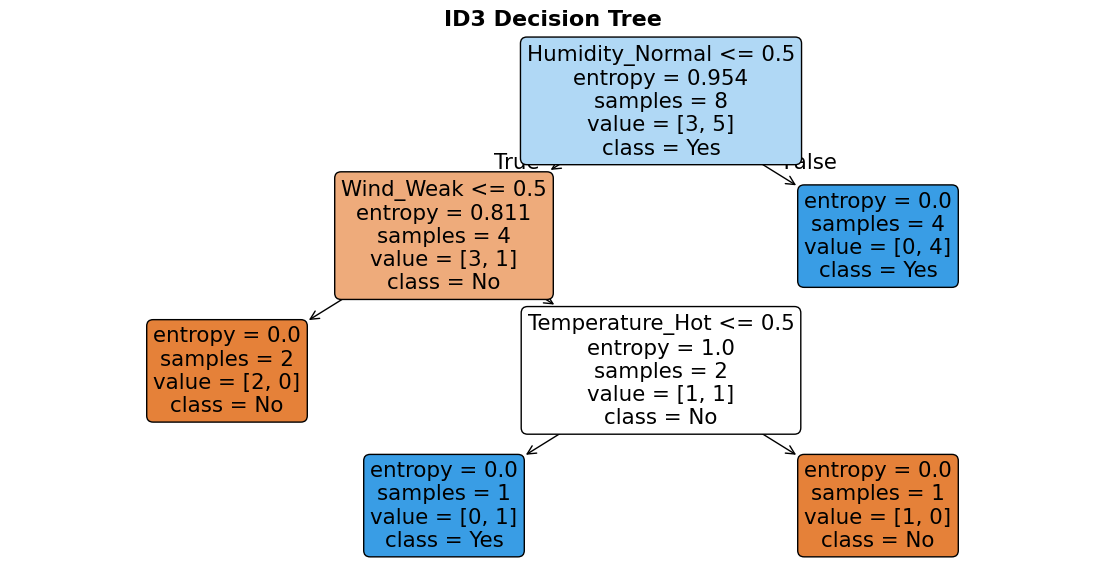

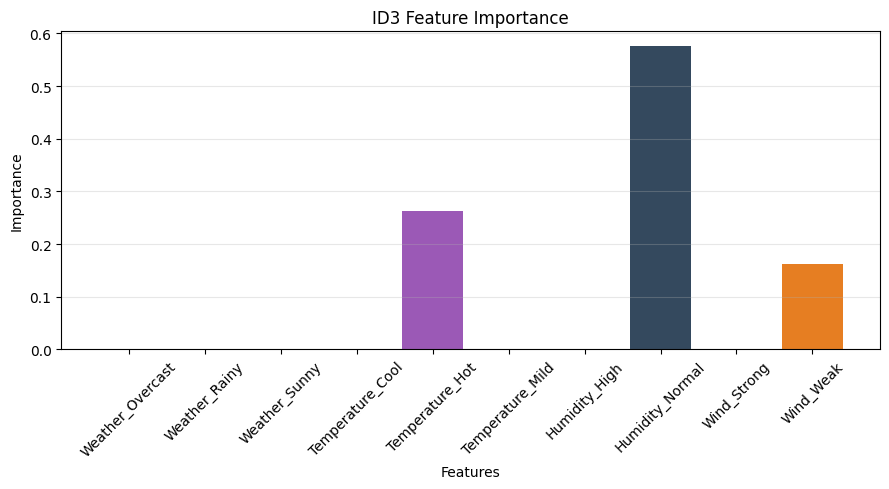

In [ ]:
# EXPERIMENT 3: ID3 DECISION TREE

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Dataset
data = {
    'Weather': ['Sunny','Sunny','Rainy','Sunny','Overcast','Overcast','Rainy','Sunny'],
    'Temperature': ['Hot','Hot','Cool','Mild','Cool','Mild','Mild','Cool'],
    'Humidity': ['High','High','Normal','High','Normal','Normal','High','Normal'],
    'Wind': ['Weak','Strong','Weak','Weak','Strong','Weak','Strong','Strong'],
    'Play': ['No','No','Yes','Yes','Yes','Yes','No','Yes']
}

df = pd.DataFrame(data)
print("Training Data:\n")
print(df)

# Convert categorical data to numbers
X = pd.get_dummies(df.drop('Play', axis=1))
y = df['Play'].map({'No': 0, 'Yes': 1})

# Build ID3 Decision Tree
model = DecisionTreeClassifier(criterion='entropy', random_state=0)
model.fit(X, y)

# Classify a new sample
new_sample = pd.DataFrame([{
    'Weather': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'Normal',
    'Wind': 'Strong'
}])

new_sample = pd.get_dummies(new_sample)
new_sample = new_sample.reindex(columns=X.columns, fill_value=0)

prediction = model.predict(new_sample)

print("\nNew Sample:")
print(new_sample)

print("\nPrediction:",
      "Yes - Play" if prediction[0] == 1 else "No - Don't Play")

# ------------------------------------------------
# GRAPH 1: Decision Tree
# ------------------------------------------------

plt.figure(figsize=(14,7))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True
)

plt.title("ID3 Decision Tree", fontsize=16, fontweight='bold')
plt.show()

# ------------------------------------------------
# GRAPH 2: Feature Importance
# ------------------------------------------------

importance = model.feature_importances_

plt.figure(figsize=(9,5))

plt.bar(
    X.columns,
    importance,
    color=['#3498DB','#E67E22','#2ECC71',
           '#E74C3C','#9B59B6','#F1C40F',
           '#1ABC9C','#34495E']
)

plt.title("ID3 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Actual Output:
[0 1 1 0]

Predicted Output:
[0 1 1 0]

Accuracy: 100.0 %


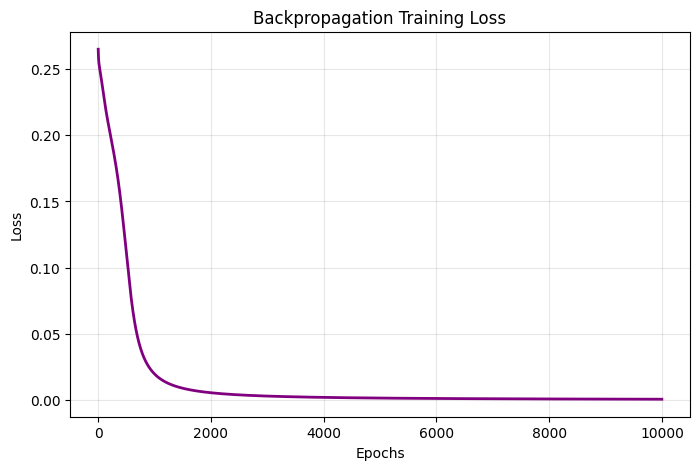

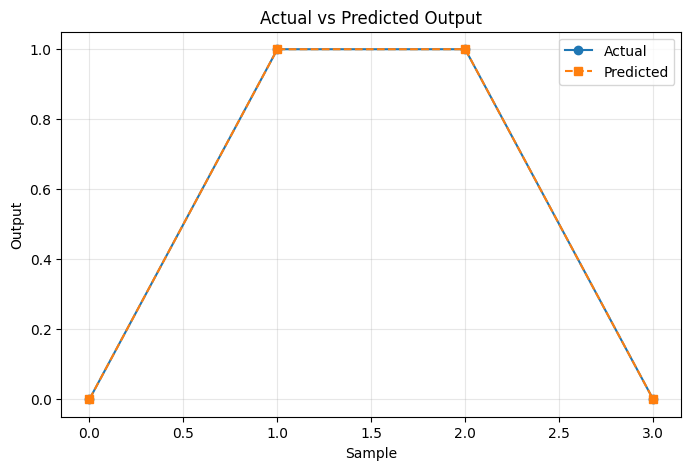

In [ ]:
# EXPERIMENT 4: ARTIFICIAL NEURAL NETWORK - BACKPROPAGATION

import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([[0],[1],[1],[0]])

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Initialize weights
np.random.seed(1)
W1 = np.random.randn(2,4)
W2 = np.random.randn(4,1)

loss_history = []

# Backpropagation training
for epoch in range(10000):

    # Forward propagation
    H = sigmoid(X @ W1)
    O = sigmoid(H @ W2)

    # Error
    error = Y - O
    loss = np.mean(error**2)
    loss_history.append(loss)

    # Backpropagation
    dO = error * sigmoid_derivative(O)
    dH = (dO @ W2.T) * sigmoid_derivative(H)

    W2 += H.T @ dO * 0.5
    W1 += X.T @ dH * 0.5

# Prediction
prediction = (O > 0.5).astype(int)

print("Actual Output:")
print(Y.flatten())

print("\nPredicted Output:")
print(prediction.flatten())

print("\nAccuracy:",
      np.mean(prediction == Y) * 100, "%")

# GRAPH 1: Loss
plt.figure(figsize=(8,5))
plt.plot(loss_history, linewidth=2, color='purple')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Backpropagation Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

# GRAPH 2: Actual vs Predicted
plt.figure(figsize=(8,5))
plt.plot(Y, 'o-', label='Actual')
plt.plot(prediction, 's--', label='Predicted')
plt.xlabel("Sample")
plt.ylabel("Output")
plt.title("Actual vs Predicted Output")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

New Sample: [5 6]
Predicted Class: 1


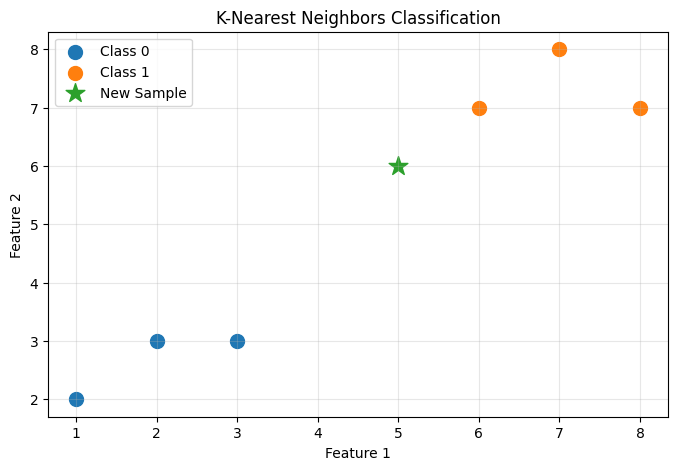

In [ ]:
# EXPERIMENT 5: K-NEAREST NEIGHBORS (KNN)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Training data
X = np.array([
    [1,2], [2,3], [3,3], [6,7], [7,8], [8,7]
])

Y = np.array([0,0,0,1,1,1])

# KNN model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, Y)

# New sample
new_sample = np.array([[5,6]])
prediction = model.predict(new_sample)

print("New Sample:", new_sample[0])
print("Predicted Class:", prediction[0])

# GRAPH: KNN classification
plt.figure(figsize=(8,5))

plt.scatter(X[Y==0,0], X[Y==0,1],
            s=100, label='Class 0')
plt.scatter(X[Y==1,0], X[Y==1,1],
            s=100, label='Class 1')

plt.scatter(new_sample[0,0], new_sample[0,1],
            s=200, marker='*', label='New Sample')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Nearest Neighbors Classification")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Actual: [0 1 0 1]
Predicted: [0 1 0 1]

Accuracy: 100.0 %

Confusion Matrix:
[[2 0]
 [0 2]]


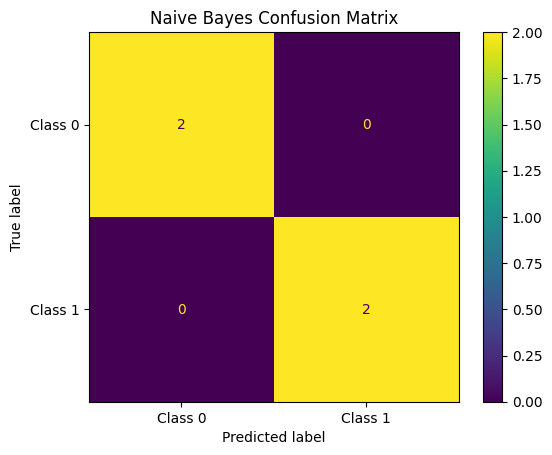

In [ ]:
# EXPERIMENT 6: NAIVE BAYES

import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Dataset
X = np.array([
    [1,2], [2,3], [2,2], [3,3],
    [6,7], [7,8], [8,7], [7,6]
])

Y = np.array([0,0,0,0,1,1,1,1])

# Naive Bayes model
model = GaussianNB()
model.fit(X, Y)

# Test data
X_test = np.array([
    [2,3],
    [7,7],
    [3,2],
    [8,6]
])

Y_test = np.array([0,1,0,1])

# Prediction
Y_pred = model.predict(X_test)

print("Actual:", Y_test)
print("Predicted:", Y_pred)

# Accuracy
accuracy = accuracy_score(Y_test, Y_pred)
print("\nAccuracy:", accuracy * 100, "%")

# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)

print("\nConfusion Matrix:")
print(cm)

# GRAPH: Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Class 0', 'Class 1']
)

disp.plot(cmap='viridis')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Test Values: [3 7]
Predicted Classes: [0 1]


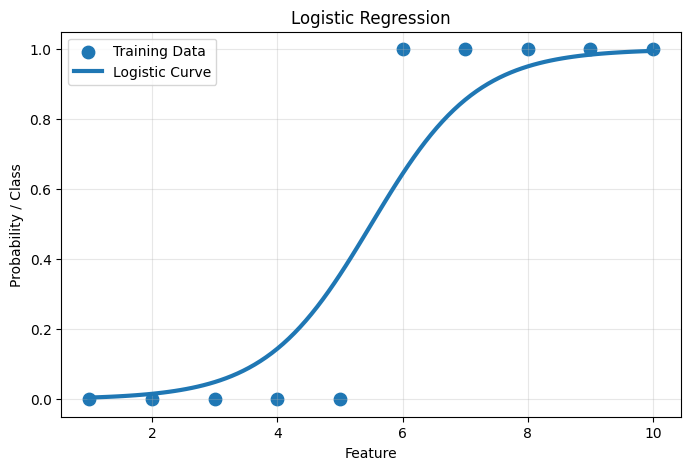

In [ ]:
# EXPERIMENT 7: LOGISTIC REGRESSION

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Training data
X = np.array([
    [1], [2], [3], [4], [5],
    [6], [7], [8], [9], [10]
])

Y = np.array([0,0,0,0,0,1,1,1,1,1])

# Create and train model
model = LogisticRegression()
model.fit(X, Y)

# Prediction
X_test = np.array([[3], [7]])
prediction = model.predict(X_test)

print("Test Values:", X_test.flatten())
print("Predicted Classes:", prediction)

# Graph
x_plot = np.linspace(1, 10, 100).reshape(-1, 1)
probability = model.predict_proba(x_plot)[:, 1]

plt.figure(figsize=(8,5))
plt.scatter(X, Y, s=80, label="Training Data")
plt.plot(x_plot, probability, linewidth=3, label="Logistic Curve")

plt.xlabel("Feature")
plt.ylabel("Probability / Class")
plt.title("Logistic Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Input: 9
Predicted Output: 18.04


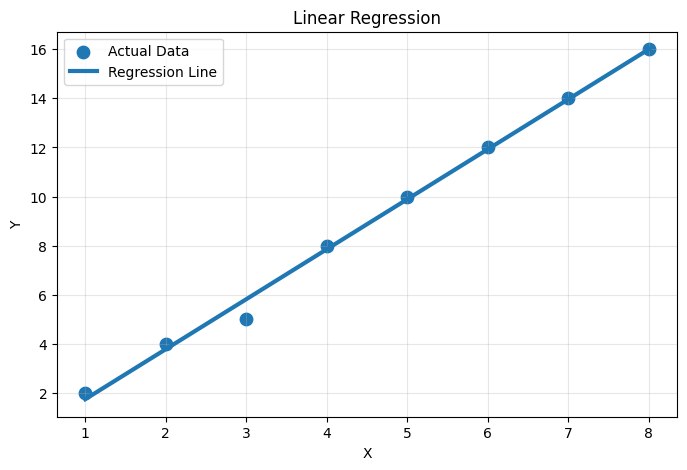

In [ ]:
# EXPERIMENT 8: LINEAR REGRESSION

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Training data
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8]])
Y = np.array([2, 4, 5, 8, 10, 12, 14, 16])

# Create and train model
model = LinearRegression()
model.fit(X, Y)

# Prediction
X_test = np.array([[9]])
prediction = model.predict(X_test)

print("Input:", X_test[0][0])
print("Predicted Output:", round(prediction[0], 2))

# Graph
Y_pred = model.predict(X)

plt.figure(figsize=(8,5))
plt.scatter(X, Y, s=80, label="Actual Data")
plt.plot(X, Y_pred, linewidth=3, label="Regression Line")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Linear Regression Prediction: 38.5
Polynomial Regression Prediction: 46.0


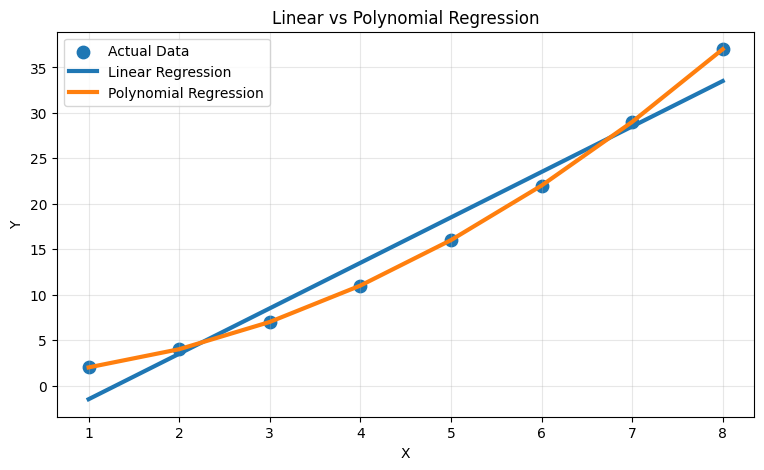

In [ ]:
# EXPERIMENT 9: LINEAR vs POLYNOMIAL REGRESSION

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Dataset
X = np.array([[1],[2],[3],[4],[5],[6],[7],[8]])
Y = np.array([2,4,7,11,16,22,29,37])

# Linear Regression
linear = LinearRegression()
linear.fit(X, Y)
Y_linear = linear.predict(X)

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

polynomial = LinearRegression()
polynomial.fit(X_poly, Y)
Y_poly = polynomial.predict(X_poly)

# Prediction
test = np.array([[9]])
linear_pred = linear.predict(test)

test_poly = poly.transform(test)
poly_pred = polynomial.predict(test_poly)

print("Linear Regression Prediction:", round(linear_pred[0], 2))
print("Polynomial Regression Prediction:", round(poly_pred[0], 2))

# Graph
plt.figure(figsize=(9,5))

plt.scatter(X, Y, s=80, label="Actual Data")
plt.plot(X, Y_linear, linewidth=3, label="Linear Regression")
plt.plot(X, Y_poly, linewidth=3, label="Polynomial Regression")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Cluster Labels:
[1 1 1 1 0 0 0 0]


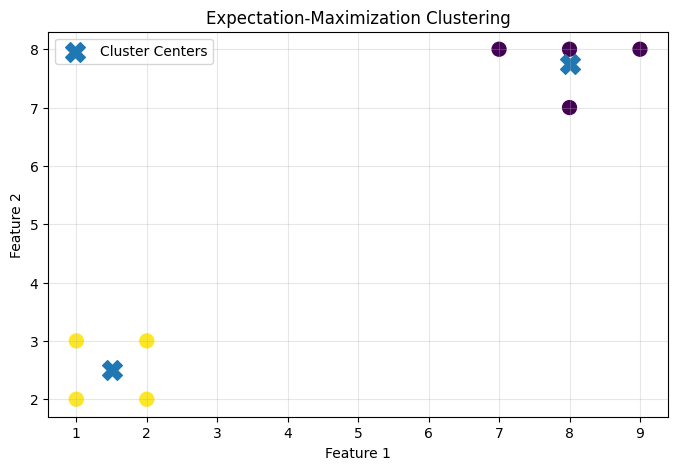

In [ ]:
# EXPERIMENT 10: EXPECTATION-MAXIMIZATION

import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Dataset
X = np.array([
    [1,2], [1,3], [2,2], [2,3],
    [7,8], [8,8], [8,7], [9,8]
])

# EM / Gaussian Mixture Model
model = GaussianMixture(n_components=2, random_state=0)
model.fit(X)

# Cluster prediction
labels = model.predict(X)

print("Cluster Labels:")
print(labels)

# Graph
plt.figure(figsize=(8,5))

plt.scatter(
    X[:,0], X[:,1],
    c=labels,
    s=100
)

plt.scatter(
    model.means_[:,0],
    model.means_[:,1],
    marker='X',
    s=200,
    label='Cluster Centers'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Expectation-Maximization Clustering")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Test Customer: [   32 45000]
Credit Score Class: Low


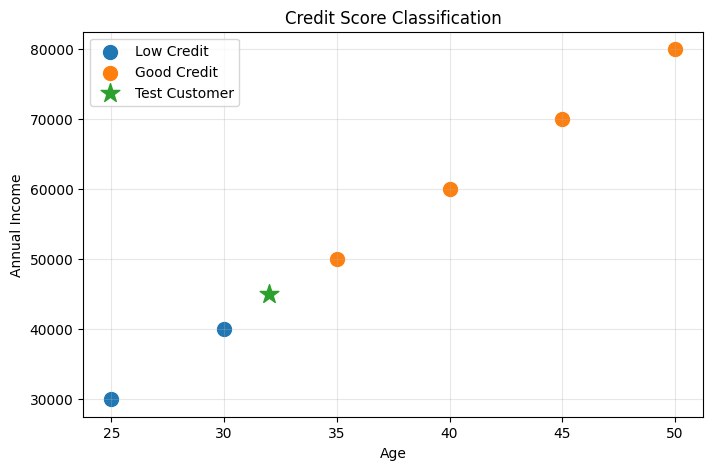

In [ ]:
# EXPERIMENT 11: CREDIT SCORE CLASSIFICATION

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Dataset
X = np.array([
    [25, 30000],
    [30, 40000],
    [35, 50000],
    [40, 60000],
    [45, 70000],
    [50, 80000]
])

# Credit score classes
# 0 = Low, 1 = Good
Y = np.array([0, 0, 1, 1, 1, 1])

# Train model
model = DecisionTreeClassifier(random_state=0)
model.fit(X, Y)

# Test customer
test = np.array([[32, 45000]])
prediction = model.predict(test)

print("Test Customer:", test[0])
print("Credit Score Class:",
      "Good" if prediction[0] == 1 else "Low")

# Graph
plt.figure(figsize=(8,5))

plt.scatter(X[Y==0,0], X[Y==0,1],
            s=100, label="Low Credit")

plt.scatter(X[Y==1,0], X[Y==1,1],
            s=100, label="Good Credit")

plt.scatter(test[0,0], test[0,1],
            s=200, marker='*', label="Test Customer")

plt.xlabel("Age")
plt.ylabel("Annual Income")
plt.title("Credit Score Classification")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Accuracy: 100.0 %
Predicted Flower: setosa


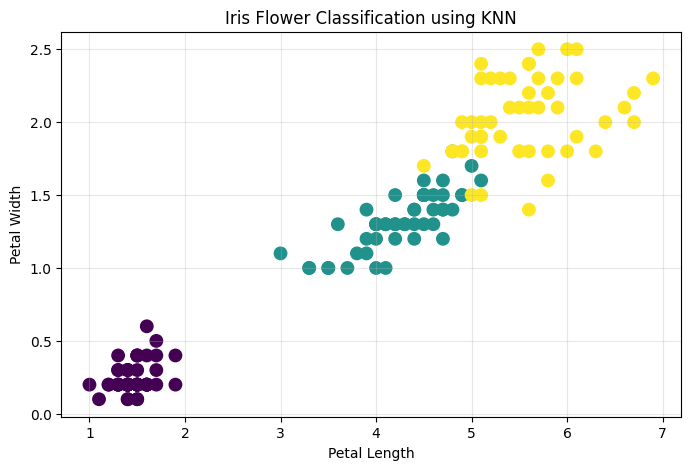

In [ ]:
# EXPERIMENT 12: IRIS FLOWER CLASSIFICATION USING KNN

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()
X = iris.data
Y = iris.target

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# KNN model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, Y_train)

# Prediction
Y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred) * 100, "%")

# Test a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(new_flower)

print("Predicted Flower:",
      iris.target_names[prediction[0]])

# Graph
plt.figure(figsize=(8,5))

plt.scatter(
    X[:,2], X[:,3],
    c=Y,
    s=80
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Flower Classification using KNN")
plt.grid(True, alpha=0.3)
plt.show()

Car Details: [3.  2.4]
Predicted Car Price: 10.06 Lakhs


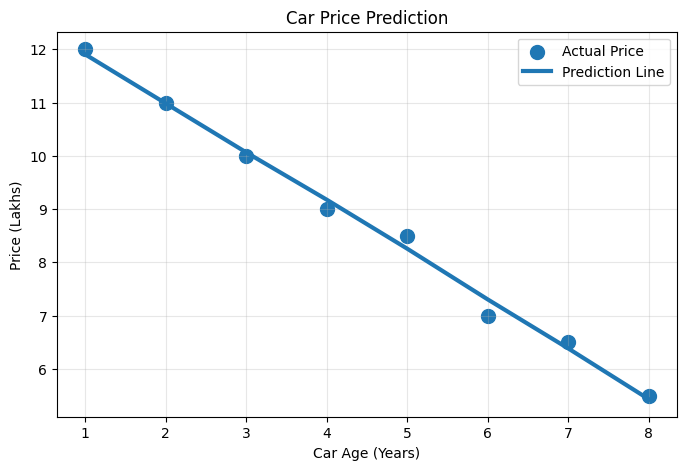

In [ ]:
# EXPERIMENT 13: CAR PRICE PREDICTION

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Dataset
# Age of car (years), Engine size (L)
X = np.array([
    [1, 2.0],
    [2, 2.2],
    [3, 2.4],
    [4, 2.5],
    [5, 2.7],
    [6, 3.0],
    [7, 3.2],
    [8, 3.5]
])

# Car prices (in lakhs)
Y = np.array([12, 11, 10, 9, 8.5, 7, 6.5, 5.5])

# Train model
model = LinearRegression()
model.fit(X, Y)

# Predict price
test = np.array([[3, 2.4]])
prediction = model.predict(test)

print("Car Details:", test[0])
print("Predicted Car Price:", round(prediction[0], 2), "Lakhs")

# Graph
plt.figure(figsize=(8,5))

plt.scatter(X[:,0], Y, s=100, label="Actual Price")
plt.plot(X[:,0], model.predict(X),
         linewidth=3, label="Prediction Line")

plt.xlabel("Car Age (Years)")
plt.ylabel("Price (Lakhs)")
plt.title("Car Price Prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# EXPERIMENT 14: HOUSE PRICE PREDICTION

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Dataset
# Area (sq.ft), Bedrooms
X = np.array([
    [800, 2],
    [1000, 2],
    [1200, 3],
    [1400, 3],
    [1600, 3],
    [1800, 4],
    [2000, 4],
    [2200, 4]
])

# House prices (in lakhs)
Y = np.array([40, 50, 60, 70, 80, 90, 100, 110])

# Train model
model = LinearRegression()
model.fit(X, Y)

# Predict price
test = np.array([[1500, 3]])
prediction = model.predict(test)

print("House Details:", test[0])
print("Predicted House Price:",
      round(prediction[0], 2), "Lakhs")

# Graph
plt.figure(figsize=(8,5))

plt.scatter(X[:,0], Y, s=100, label="Actual Prices")
plt.plot(X[:,0], model.predict(X),
         linewidth=3, label="Prediction Line")

plt.xlabel("Area (sq.ft)")
plt.ylabel("Price (Lakhs)")
plt.title("House Price Prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Accuracy: 100.0 %
Predicted Flower: setosa


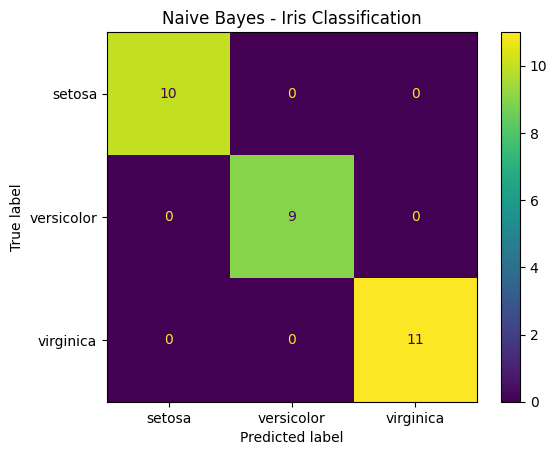

In [ ]:
# EXPERIMENT 15: IRIS CLASSIFICATION USING NAIVE BAYES

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load Iris dataset
iris = load_iris()
X = iris.data
Y = iris.target

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Naive Bayes model
model = GaussianNB()
model.fit(X_train, Y_train)

# Prediction
Y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred) * 100, "%")

# Test a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(new_flower)

print("Predicted Flower:",
      iris.target_names[prediction[0]])

# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap='viridis')
plt.title("Naive Bayes - Iris Classification")
plt.show()

Classification Algorithm Performance:

KNN : 100.0 %
Decision Tree : 96.67 %
Naive Bayes : 96.67 %
Logistic Regression : 100.0 %


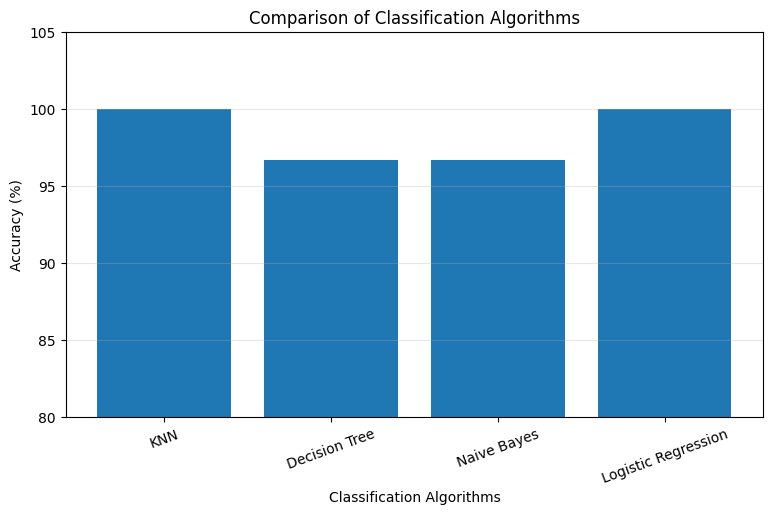

In [20]:
# EXPERIMENT 16: COMPARISON OF CLASSIFICATION ALGORITHMS

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Load Iris dataset
iris = load_iris()
X = iris.data
Y = iris.target

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=0,
    stratify=Y
)

# Classification algorithms
models = {
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=200)
}

accuracy = {}

# Train and test each algorithm
for name, model in models.items():
    model.fit(X_train, Y_train)
    prediction = model.predict(X_test)
    accuracy[name] = accuracy_score(Y_test, prediction) * 100

# Display results
print("Classification Algorithm Performance:\n")

for name, score in accuracy.items():
    print(name, ":", round(score, 2), "%")

# Graph
plt.figure(figsize=(9,5))

plt.bar(accuracy.keys(), accuracy.values())

plt.xlabel("Classification Algorithms")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Classification Algorithms")
plt.ylim(80, 105)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)

plt.show()

Mobile Details: [   8 5000  256]
Predicted Price Category: High Price


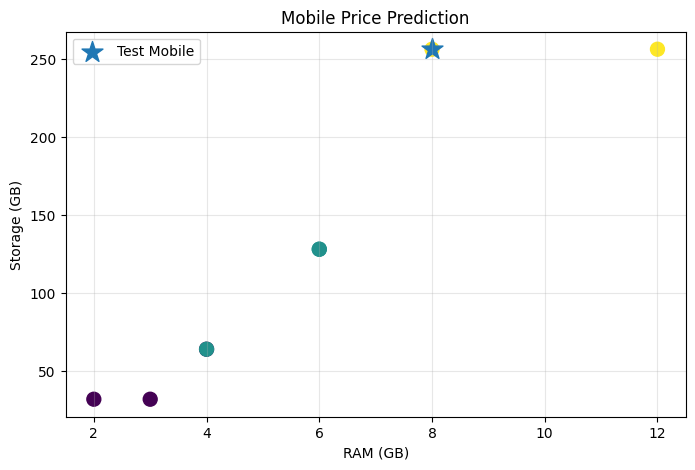

In [ ]:
# EXPERIMENT 17: MOBILE PRICE PREDICTION

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Dataset
# RAM (GB), Battery (mAh), Storage (GB)
X = np.array([
    [2, 3000, 32],
    [3, 3500, 32],
    [4, 4000, 64],
    [4, 4500, 64],
    [6, 4500, 128],
    [6, 5000, 128],
    [8, 5000, 256],
    [12, 5000, 256]
])

# Price categories
# 0 = Low, 1 = Medium, 2 = High
Y = np.array([0, 0, 0, 1, 1, 1, 2, 2])

# Train model
model = RandomForestClassifier(n_estimators=50, random_state=0)
model.fit(X, Y)

# Test mobile
test = np.array([[8, 5000, 256]])
prediction = model.predict(test)

prices = {
    0: "Low Price",
    1: "Medium Price",
    2: "High Price"
}

print("Mobile Details:", test[0])
print("Predicted Price Category:", prices[prediction[0]])

# Graph
plt.figure(figsize=(8,5))

plt.scatter(
    X[:,0], X[:,2],
    c=Y,
    s=100
)

plt.scatter(
    test[0,0], test[0,2],
    marker='*',
    s=250,
    label="Test Mobile"
)

plt.xlabel("RAM (GB)")
plt.ylabel("Storage (GB)")
plt.title("Mobile Price Prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Accuracy: 80.0 %
Predicted Flower: setosa


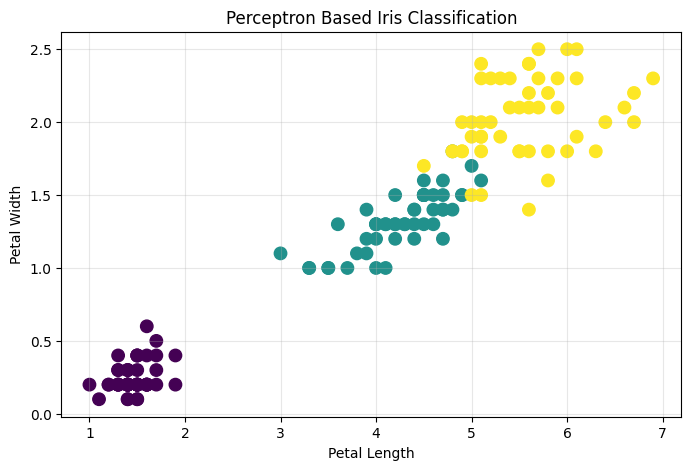

In [ ]:
# EXPERIMENT 18: PERCEPTRON BASED IRIS CLASSIFICATION

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()
X = iris.data
Y = iris.target

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Perceptron model
model = Perceptron(max_iter=1000, random_state=0)
model.fit(X_train, Y_train)

# Prediction
Y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred) * 100, "%")

# Test a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(new_flower)

print("Predicted Flower:",
      iris.target_names[prediction[0]])

# Graph
plt.figure(figsize=(8,5))

plt.scatter(
    X[:,2], X[:,3],
    c=Y,
    s=80
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Perceptron Based Iris Classification")
plt.grid(True, alpha=0.3)
plt.show()

Actual: [1 1]
Predicted: [0 1]

Accuracy: 50.0 %

New Applicant: [55000 22000   710]
Loan Status: Approved


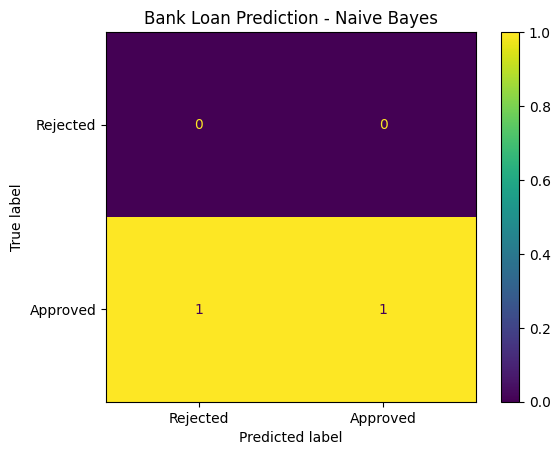

In [ ]:
# EXPERIMENT 19: BANK LOAN PREDICTION USING NAIVE BAYES

import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Dataset
# Income, Loan Amount, Credit Score
X = np.array([
    [30000, 10000, 600],
    [35000, 12000, 620],
    [40000, 15000, 650],
    [45000, 18000, 680],
    [50000, 20000, 700],
    [60000, 25000, 720],
    [70000, 30000, 750],
    [80000, 35000, 780]
])

# 0 = Loan Rejected, 1 = Loan Approved
Y = np.array([0, 0, 0, 1, 1, 1, 1, 1])

# Train model
model = GaussianNB()
model.fit(X, Y)

# Test data
X_test = np.array([
    [42000, 16000, 660],
    [75000, 30000, 760]
])

Y_test = np.array([1, 1])

# Prediction
Y_pred = model.predict(X_test)

print("Actual:", Y_test)
print("Predicted:", Y_pred)

print("\nAccuracy:",
      accuracy_score(Y_test, Y_pred) * 100, "%")

# New applicant
new_applicant = np.array([[55000, 22000, 710]])
prediction = model.predict(new_applicant)

print("\nNew Applicant:", new_applicant[0])
print("Loan Status:",
      "Approved" if prediction[0] == 1 else "Rejected")

# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected", "Approved"]
)

disp.plot(cmap='viridis')
plt.title("Bank Loan Prediction - Naive Bayes")
plt.show()

Future Sales Prediction:
Month 9 : 260.0
Month 10 : 280.0
Month 11 : 300.0


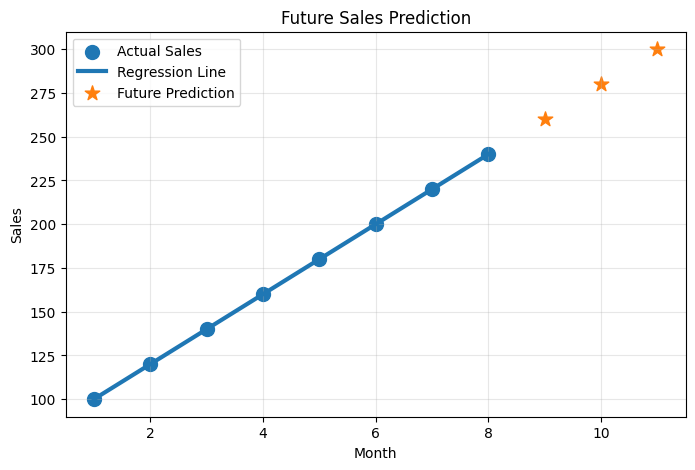

In [ ]:
# EXPERIMENT 20: FUTURE SALES PREDICTION

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Dataset
# Month and Sales
X = np.array([[1],[2],[3],[4],[5],[6],[7],[8]])
Y = np.array([100,120,140,160,180,200,220,240])

# Train model
model = LinearRegression()
model.fit(X, Y)

# Predict future sales
future = np.array([[9],[10],[11]])
prediction = model.predict(future)

print("Future Sales Prediction:")

for month, sales in zip(future.flatten(), prediction):
    print("Month", month, ":", round(sales, 2))

# Graph
plt.figure(figsize=(8,5))

plt.scatter(X, Y, s=100, label="Actual Sales")
plt.plot(X, model.predict(X),
         linewidth=3, label="Regression Line")

plt.scatter(
    future, prediction,
    s=120, marker='*',
    label="Future Prediction"
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Future Sales Prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()